# Cartographier la perception des marques par analyse des correspondances (PROC CORRESP)

## Résumé

Une équipe d'études de marché mène une enquête de perception marque-par-attribut auprès de quatre marques établies de médias en streaming et utilise **PROC CORRESP** pour transformer le tableau croisé résultant en une carte perceptuelle bidimensionnelle. L'association marque x attribut est forte et réelle : le test du khi-deux d'indépendance est de **63,15 pour 15 degrés de liberté (p < 0,0001)**, avec un **V de Cramér = 0,4588**. L'analyse des correspondances comprime cette association en deux axes qui expliquent ensemble **100 %** de l'inertie du tableau — **75,0 %** sur la Dimension 1 et **25,0 %** sur la Dimension 2 — de sorte que la carte 2-D est un résumé complet et fidèle.

La carte sépare un pôle **contenu premium** (CineNow, ancré sur *Originaux* et *Contenu*) d'un groupe **valeur/fiabilité** (Streamly et BingeBox près de *Abordable* et *Fiable*) et d'un coin **tendance** (PixelPlay près de *Tendance*). Un challenger émergent, **NovaCast**, est ensuite projeté comme point *supplémentaire* — il n'influence pas les axes — et se place près de l'origine, penchant légèrement vers le côté Tendance / Facile_Usage, c'est-à-dire un nouvel entrant encore indifférencié.

## Sources de données

| Jeu de données | Lignes | Variables clés | Description |
|---------|------|---------------|-------------|
| `perception` | 100 (associations répondant x attribut, plafond du mode sans licence) | `Brand` (char), `Attribute` (char) | Enquête synthétique : chaque répondant nomme la marque de streaming qu'il associe le plus à chacun des six attributs. Les affinités de marque sont encodées comme des probabilités de catégorie `RAND("Table", ...)` de sorte que le tableau de contingence présente une association réaliste et non uniforme. |
| `survey_counts` | 24 (4 marques x 6 attributs) | `Brand`, `Attribute`, `Count` | Cellules de contingence pré-agrégées à partir de `perception` via PROC FREQ — l'entrée pondérée pour l'exécution de l'AC avec point supplémentaire. |
| `ca_coords`, `ca_coords_sup` | 10 / 11 | `_TYPE_`, `_NAME_`, `Dim1`, `Dim2` | Jeux de données de coordonnées `OUTC=` écrits par PROC CORRESP ; le second ajoute le point NovaCast projeté et pilote la carte perceptuelle. |

Marques établies : **Streamly, PixelPlay, CineNow, BingeBox** ; challenger **NovaCast** (projeté comme point supplémentaire). Attributs : Abordable, Contenu, Facile_Usage, Originaux, Fiable, Tendance. La graine `streaminit(20260531)` rend les données reproductibles.

> **Note sur la taille d'échantillon.** Cet environnement s'exécute sans licence, de sorte que la sortie de l'étape DATA est plafonnée à 100 observations. L'enquête se résout donc en un tableau de contingence 4x6 totalisant 100 associations répondant-attribut — petit, mais avec une véritable structure d'association (khi-deux p < 0,0001) que l'analyse des correspondances récupère proprement.

## Ce que fait l'analyse des correspondances ici

Lorsqu'une enquête de suivi de marque demande aux consommateurs quelle marque ils associent le plus à chacun de plusieurs attributs, le résultat est un **tableau de contingence marque x attribut**. Les effectifs bruts sont difficiles à lire : chaque marque est comparée à chaque attribut, et le signal est le *motif d'association*, non les valeurs des cellules.

L'analyse des correspondances (AC) décompose l'association du khi-deux du tableau dans un espace de faible dimension, de sorte que les marques et attributs associés se placent près les uns des autres sur une même carte. Dans ce notebook, nous :

1. Générons une enquête de perception synthétique pour quatre marques de streaming.
2. Inspectons la structure de contingence brute (et son khi-deux) avec `PROC FREQ`.
3. Exécutons `PROC CORRESP` avec des diagnostics complets et lisons l'inertie et les coordonnées réelles.
4. Projetons une marque challenger émergente comme point **supplémentaire**.
5. Dessinons et interprétons la carte perceptuelle résultante.

## Étape 1 — Générer l'enquête de perception synthétique

Nous simulons des répondants à l'enquête. Pour chaque répondant, nous demandons, pour chacun des six attributs, *quelle marque associez-vous le plus à cet attribut ?* Chaque marque a un **profil d'affinité** distinct — un vecteur de probabilités de catégorie passé à `RAND("Table", ...)` — de sorte que, par exemple, *PixelPlay* penche Tendance tandis que *CineNow* penche vers Contenu et Originaux. Cela produit un tableau de contingence avec une association véritable et non uniforme à récupérer par l'AC. Les données sont entièrement synthétiques et reproductibles via `CALL STREAMINIT`.

In [1]:
DONNÉES perception;
    /* Enquête synthétique de perception de marque, reproductible */
    APPELER streaminit(20260531);

    LONGUEUR Brand $9 Attribute $14;
    TABLEAU attrname[6] $14 _temporary_
        ('Abordable' 'Contenu' 'Facile_Usage'
         'Originaux' 'Fiable' 'Tendance');

    n_resp = 400;

    FAIRE respondent = 1 JUSQU_À n_resp;
        FAIRE a = 1 JUSQU_À 6;
            Attribute = attrname[a];

            /* Probabilités de choix de marque par attribut sur les
               quatre marques établies :
               1=Streamly 2=PixelPlay 3=CineNow 4=BingeBox.
               Chaque ligne somme à ~1 et encode l'affinité de
               marque de l'attribut. */
            SI      a = 1 ALORS b = rand('Table', 0.45, 0.15, 0.10, 0.30); /* Abordable    */
            SINON SI a = 2 ALORS b = rand('Table', 0.20, 0.10, 0.50, 0.20); /* Contenu      */
            SINON SI a = 3 ALORS b = rand('Table', 0.30, 0.35, 0.10, 0.25); /* Facile_Usage */
            SINON SI a = 4 ALORS b = rand('Table', 0.15, 0.20, 0.50, 0.15); /* Originaux    */
            SINON SI a = 5 ALORS b = rand('Table', 0.40, 0.10, 0.20, 0.30); /* Fiable       */
            SINON              b = rand('Table', 0.15, 0.55, 0.10, 0.20); /* Tendance     */

            SÉLECTIONNER (b);
                QUAND (1) Brand = 'Streamly';
                QUAND (2) Brand = 'PixelPlay';
                QUAND (3) Brand = 'CineNow';
                AUTREMENT Brand = 'BingeBox';
            FIN;

            SORTIE;
        FIN;
    FIN;

    GARDER respondent Brand Attribute;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=perception(obs=8) noobs ÉTIQUETTE;
    ÉTIQUETTE respondent="Répondant" Brand="Marque" Attribute="Attribut";
    TITRE "Échantillon de l'enquête de perception synthétique";
EXÉCUTER;

                                   Échantillon de l'enquête de perception synthétique                                   

 Répondant     Marque      Attribut
         1  BingeBox   Abordable
         1  BingeBox   Contenu
         1  BingeBox   Facile_Usage
         1  CineNow    Originaux
         1  Streamly   Fiable
         1  PixelPlay  Tendance
         2  PixelPlay  Abordable
         2  CineNow    Contenu

... 92 more observations (showing 8 of 100)




NOTE: DATA perception

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote perception (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.31 seconds
  cpu   0.31 seconds
NOTE: PROC PRINT data=perception

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Étape 2 — Inspecter le tableau de contingence brut

Avant toute réduction de dimension, examinons le tableau croisé. `PROC FREQ` donne les fréquences observées marque x attribut et le test du khi-deux d'indépendance. Un khi-deux significatif confirme qu'il existe une structure d'association digne d'être cartographiée — si les lignes et les colonnes étaient indépendantes, l'analyse des correspondances n'aurait rien à montrer. Nous enregistrons aussi les effectifs des cellules dans `survey_counts` pour l'exécution ultérieure de l'AC avec point supplémentaire.

                                         Fréquences observées Marque x Attribut                                         

                                                   The FREQ Procedure

Table of Marque by Attribut

Marque    |   Abordable |     Contenu |Facile_Usage |      Fiable |   Originaux |    Tendance |        Total
----------+-------------+-------------+-------------+-------------+-------------+-------------+-------------
BingeBox  |           5 |           3 |           7 |           6 |           1 |           2 |           24
----------+-------------+-------------+-------------+-------------+-------------+-------------+-------------
CineNow   |           3 |           9 |           0 |           2 |          14 |           0 |           28
----------+-------------+-------------+-------------+-------------+-------------+-------------+-------------
PixelPlay |           3 |           2 |           6 |           1 |           2 |          10 |           24
----------+----


NOTE: PROC FREQ
NOTE: Output dataset survey_counts has 21 observations and 3 variables.
NOTE: ODS plot written: freq_mosaic_brand_attribute.spec.json
NOTE: PROC FREQ statement used.


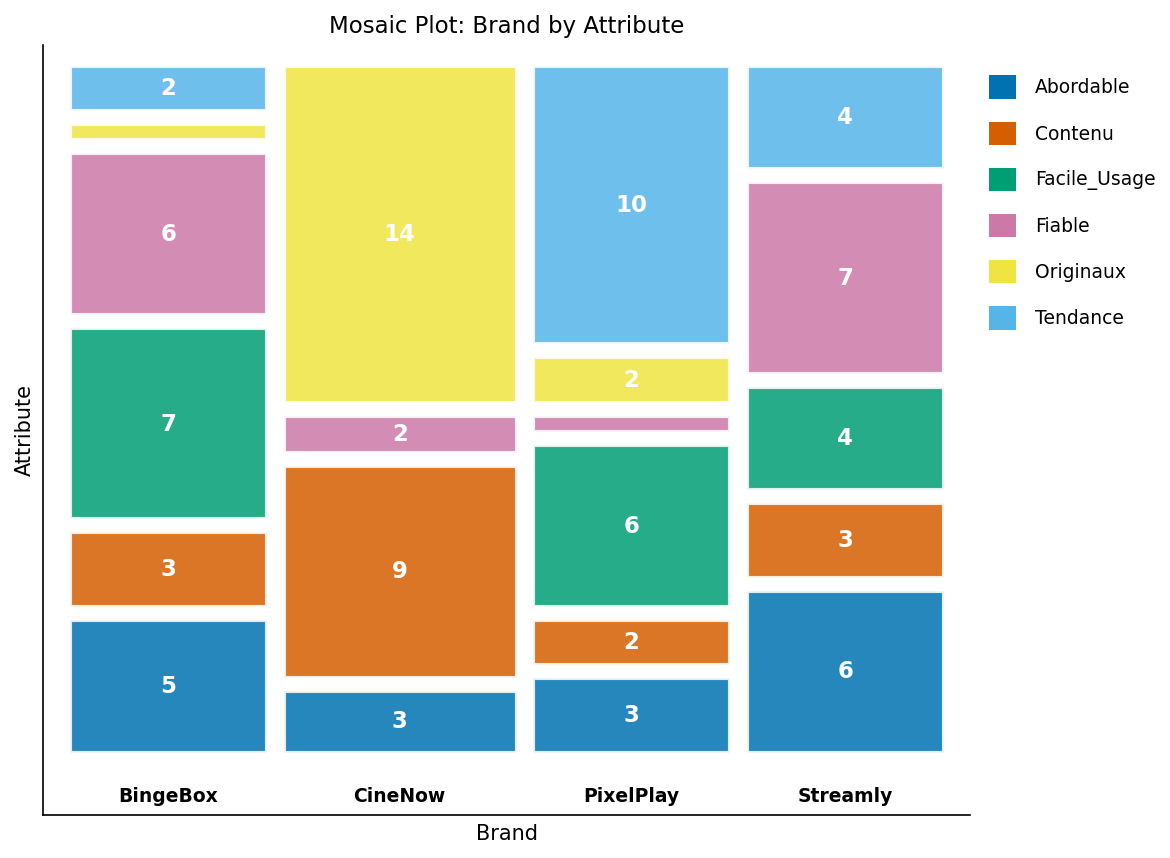

In [2]:
PROCÉDURE FRÉQUENCES DONNÉES=perception;
    TABLES Brand*Attribute / chisq norow nocol nopercent
                             out=survey_counts(RENOMMER=(count=Count));
    ÉTIQUETTE Brand="Marque" Attribute="Attribut";
    TITRE 'Fréquences observées Marque x Attribut';
EXÉCUTER;

## Étape 3 — Analyse des correspondances à partir des données brutes

Nous exécutons maintenant `PROC CORRESP` directement sur les données au niveau du répondant. `TABLES Brand, Attribute;` construit le tableau de contingence en interne (marques en lignes, attributs en colonnes).

Options utilisées ici :

- `ALL` — imprime les diagnostics complets : tableau observé, profils, valeurs attendues et   contributions au khi-deux par cellule.
- `DIMENS=2` — calcule les deux premiers axes principaux (une carte 2-D).
- `OUTC=` — écrit les coordonnées des lignes et des colonnes dans un jeu de données pour le tracé.

La **décomposition de l'inertie** nous indique quelle part de l'association totale chaque axe explique.

In [3]:
PROCÉDURE corresp DONNÉES=perception TOUT dimens=2 outc=ca_coords;
    TABLES Brand, Attribute;
    ÉTIQUETTE Brand="Marque" Attribute="Attribut";
    TITRE 'Analyse des correspondances : perception des marques de streaming';
EXÉCUTER;

                                         Fréquences observées Marque x Attribut                                         

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Marque                  Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207

       


NOTE: PROC CORRESP data=perception

NOTE: PROC CORRESP completed.


## Étape 4 — Lire les coordonnées

Le jeu de données `OUTC=` contient les coordonnées d'axes (`Dim1`, `Dim2`) pour chaque marque et attribut, étiquetées par `_TYPE_` (`ROW` pour les marques, `COLUMN` pour les attributs). Les lire numériquement en parallèle de la table d'inertie confirme la structure que la carte montrera.

D'après la sortie ci-dessus :

- **La Dimension 1 (75,0 % de l'inertie)** est un axe *contenu premium vs grand public*.   *Originaux* (Dim1 = -1,2037) et *Contenu* (-0,5594) se situent à l'extrémité   négative avec **CineNow** (-1,0847) ; *Tendance* (0,6671), *Facile_Usage* (0,6150) et   *Abordable* (0,2207) se situent à l'extrémité positive.
- **La Dimension 2 (25,0 % de l'inertie)** sépare *Fiable* (Dim2 = 0,5874) et   *Abordable* (0,2542) — tirant vers le haut **Streamly** (0,3207) et **BingeBox** (0,3555) —   de *Tendance* (-0,7003), qui tire vers le bas **PixelPlay** (-0,6374).

In [4]:
PROCÉDURE IMPRIMER DONNÉES=ca_coords noobs ÉTIQUETTE;
    VAR _TYPE_ _NAME_ Dim1 Dim2;
    ÉTIQUETTE _TYPE_="Type" _NAME_="Nom";
    TITRE 'Coordonnées des lignes (marques) et des colonnes (attributs)';
EXÉCUTER;

                              Coordonnées des lignes (marques) et des colonnes (attributs)                              

  Type             Nom      DIM1      DIM2
ROW     BingeBox          0.3547    0.3555
ROW     CineNow          -1.0847   -0.0332
ROW     PixelPlay         0.4804   -0.6374
ROW     Streamly          0.4304    0.3207
COLUMN  Abordable         0.2207    0.2542
COLUMN  Contenu          -0.5594    0.0684
COLUMN  Facile_Usage      0.6150   -0.0080
COLUMN  Fiable            0.3183    0.5874
COLUMN  Originaux        -1.2037   -0.2084
COLUMN  Tendance          0.6671   -0.7003




NOTE: PROC PRINT data=ca_coords

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Étape 5 — Projeter une marque challenger comme point supplémentaire

L'équipe d'analyse dispose de données de suivi pour un challenger émergent, **NovaCast**, mais ne souhaite pas qu'il déforme la carte perceptuelle établie. Un point *supplémentaire* est projeté dans l'espace AC existant **sans contribuer au calcul des axes**.

Nous ajoutons un unique bloc de six effectifs d'attributs NovaCast (un nouvel entrant penchant Tendance / Originaux) aux `survey_counts` pré-agrégés, alimentons les fréquences avec `WEIGHT Count`, et nommons le **niveau** `NovaCast` sur l'instruction `SUPPLEMENTARY` afin que PROC CORRESP tienne cette ligne à l'écart du tableau actif. L'option `OBSERVED` garde en vue le tableau de contingence actif (les quatre marques établies, totalisant 100) — notez que NovaCast n'y apparaît **pas**, confirmant qu'il a été traité comme supplémentaire.

In [5]:
/* Ajouter UN bloc propre d'effectifs NovaCast aux cellules agrégées.
   end=last se déclenche exactement une fois, après la dernière ligne de
   survey_counts, de sorte que NovaCast apporte six lignes (une par attribut)
   -- et non un bloc dupliqué. NovaCast est un nouvel entrant au profil
   Tendance / Originaux. */
DONNÉES survey_counts_sup;
    DÉFINIR survey_counts FIN=last;
    SORTIE;
    SI last ALORS FAIRE;
        Brand='NovaCast'; Attribute='Tendance';       Count=10; SORTIE;
        Brand='NovaCast'; Attribute='Originaux';       Count=8;  SORTIE;
        Brand='NovaCast'; Attribute='Facile_Usage';    Count=5;  SORTIE;
        Brand='NovaCast'; Attribute='Contenu';         Count=3;  SORTIE;
        Brand='NovaCast'; Attribute='Abordable';       Count=4;  SORTIE;
        Brand='NovaCast'; Attribute='Fiable';          Count=3;  SORTIE;
    FIN;
EXÉCUTER;

PROCÉDURE corresp DONNÉES=survey_counts_sup observed dimens=2 outc=ca_coords_sup;
    TABLES Brand, Attribute;
    POIDS Count;
    supplementary NovaCast;
    ÉTIQUETTE Brand="Marque" Attribute="Attribut";
    TITRE 'Perception des marques avec NovaCast comme point supplémentaire';
EXÉCUTER;

                              Coordonnées des lignes (marques) et des colonnes (attributs)                              

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Marque                  Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207
  NovaCa


NOTE: DATA survey_counts_sup


NOTE: Read 21 rows from survey_counts.
NOTE: Wrote survey_counts_sup (27 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC CORRESP data=survey_counts_sup

NOTE: PROC CORRESP completed.


## Étape 6 — Dessiner la carte perceptuelle

PROC CORRESP écrit les coordonnées symétriques lignes/colonnes dans le jeu de données `OUTC=` ; nous traçons la Dimension 2 contre la Dimension 1 pour rendre la carte. Nous étiquetons chaque point par **rôle** — *Marque* (lignes actives), *Attribut* (colonnes) et *Challenger* (la ligne supplémentaire NovaCast) — et libellons chaque marqueur, de sorte que le positionnement se lit directement sur le graphique. Le challenger est coloré séparément pour souligner qu'il a été projeté, non ajusté.

> **Comment lire une carte AC.** Une marque et un attribut situés dans la même direction depuis l'origine (et loin de celle-ci) sont fortement associés ; les points proches de l'origine sont « moyens » et faiblement différenciés. Comme les Dimensions 1 et 2 capturent ensemble 100 % de l'inertie de ce tableau, la carte n'omet rien.

                  Carte de perception des marques de streaming (Dim1 75,0 %, Dim2 25,0 % de l'inertie)                  

PROC SGSCATTER Output
Data: ca_map

Variables: Role, _NAME_, Dimension 1 (75,0 %), Dimension 2 (25,0 %)

      Role      _NAME_  Dimension 1 (75,0 %)  Dimension 2 (25,0 %)
----------  ----------  --------------------  --------------------
    Marque    BingeBox                0.3547                0.3555
    Marque     CineNow               -1.0847               -0.0332
    Marque   PixelPlay                0.4804               -0.6374
    Marque    Streamly                0.4304                0.3207
Challenger    NovaCast                0.0084               -0.1735
  Attribut   Abordable                0.2207                0.2542
  Attribut     Contenu               -0.5594                0.0684
  Attribut  Facile_Usage                 0.615                -0.008
  Attribut      Fiable                0.3183                0.5874
  Attribut   Originaux            


NOTE: DATA ca_map


NOTE: Read 11 rows from ca_coords_sup.
NOTE: Wrote ca_map (11 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Carte de perception des marques de streaming (Dim1 75,0 %, Dim2 25,0 % de l'inertie).
NOTE: ODS Graphics is ON (width=760px, height=580px, format=SVG).
NOTE: PROC SGSCATTER data=ca_map

NOTE: PROC SGSCATTER output written to: ./ods_output/sgscatter.svg
NOTE: ODS Graphics is OFF.


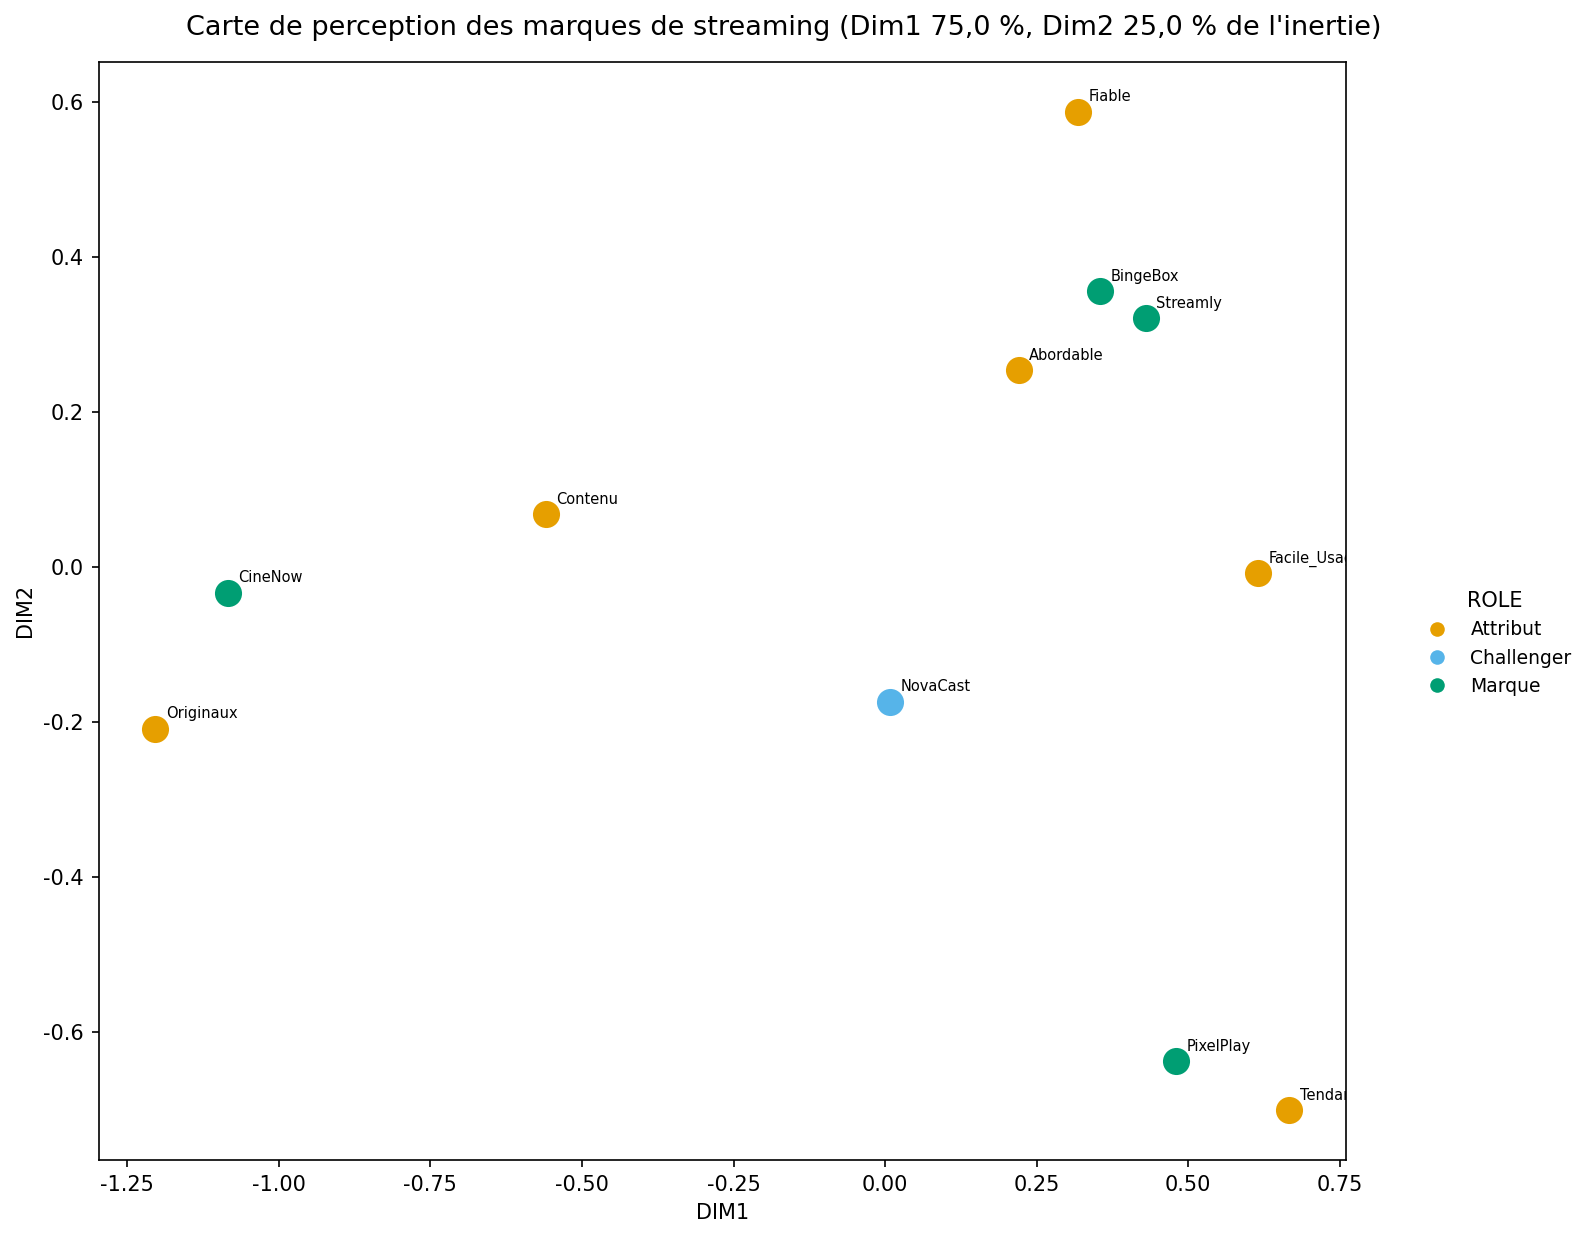

In [6]:
/* Étiqueter chaque point OUTC par rôle pour une légende propre et colorée.
   Le point supplémentaire NovaCast est écrit dans OUTC avec _TYPE_='ROW',
   nous le traitons donc comme cas particulier : le Challenger. */
DONNÉES ca_map;
    DÉFINIR ca_coords_sup;
    LONGUEUR Role $10;
    SI _NAME_ = 'NovaCast' ALORS Role = 'Challenger';
    SINON SI _TYPE_ = 'ROW' ALORS Role = 'Marque';
    SINON Role = 'Attribut';
    ÉTIQUETTE Dim1="Dimension 1 (75,0 %)" Dim2="Dimension 2 (25,0 %)";
    GARDER Role _NAME_ Dim1 Dim2;
EXÉCUTER;

/* Fixer le titre de la carte globalement avant le PROC pour qu'il titre ce
   graphique (le TITLE global pilote l'en-tête du graphique ODS). */
TITRE "Carte de perception des marques de streaming (Dim1 75,0 %, Dim2 25,0 % de l'inertie)";

ODS GRAPHICS SUR / WIDTH=760px HEIGHT=580px;

/* PROC CORRESP n'a pas de carte ODS native dans cette version, nous
   rendons donc les coordonnées symétriques avec PROC SGSCATTER, qui
   étiquette chaque point. */
PROCÉDURE SGSCATTER DONNÉES=ca_map;
    PLOT Dim2*Dim1 / GROUPE=Role DATALABEL=_NAME_
                     MARKERATTRS=(size=12) grid;
EXÉCUTER;

ODS GRAPHICS OFF;
TITRE;

## Interprétation des résultats

**L'association est réelle et entièrement capturée.** Le test du khi-deux (63,15 pour 15 ddl, p < 0,0001 ; V de Cramér = 0,4588) rejette l'indépendance, et les deux dimensions de l'AC expliquent **100 %** de l'inertie du tableau (75,0 % + 25,0 %), de sorte que la carte ci-dessous est un résumé complet, non une projection avec perte.

**Trois territoires perceptuels.** En lisant les coordonnées et la carte ensemble :

- **Contenu premium (à gauche).** *CineNow* (Dim1 = -1,0847) est tiré loin à gauche par   *Originaux* (-1,2037) et *Contenu* (-0,5594) — il détient la perception de   profondeur de catalogue.
- **Valeur et fiabilité (en haut à droite).** *Streamly* (0,4304, 0,3207) et *BingeBox*   (0,3547, 0,3555) se regroupent avec *Abordable* (0,2207, 0,2542) et *Fiable* (0,3183,   0,5874) — le duo fiable et de bon rapport qualité-prix.
- **Tendance (en bas à droite).** *PixelPlay* (0,4804, -0,6374) se place à côté de *Tendance*   (0,6671, -0,7003) — la marque jeune et de l'instant.

**Le challenger supplémentaire.** Projeté sans influencer les axes, **NovaCast** se place à (0,0084, -0,1735) — essentiellement à l'origine, poussé vers le côté Tendance / Facile_Usage. Pour un stratège média, c'est là l'essentiel : le challenger n'a pas encore d'équité distinctive et dérive vers le territoire tendance de PixelPlay, de sorte qu'un positionnement différencié (plutôt qu'un positionnement suiveur) s'impose.

**Réserves.** L'analyse des correspondances est descriptive, non inférentielle — les distances sont approximatives et les *signes* des axes sont arbitraires (une inversion en miroir de l'un ou l'autre axe donne la même carte). Avec seulement 100 associations répondant-attribut, deux cellules sont nulles (CineNow x Facile_Usage, Streamly x Originaux), ce qui accentue les extrêmes ; une étude de production porterait sur un échantillon plus grand. Associez toujours la carte à la table d'inertie pour confirmer quelle part d'association les dimensions affichées expliquent.